# 🏡 HousePriceAI

## Indian House Price Prediction using Machine Learning

### Internship Project

### 📌 Objective
Predict the price of a house based on various housing features using Machine Learning.

---

## Workflow

✔ Import Libraries

✔ Load Dataset

✔ Data Exploration

✔ Data Cleaning

✔ Exploratory Data Analysis

✔ Data Preprocessing

✔ Train-Test Split

✔ Linear Regression Model

✔ Model Evaluation

✔ Save Trained Model

---

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Joblib
- Flask

In [2]:
# ============================================
# HousePriceAI
# Import Required Libraries
# ============================================

import warnings
warnings.filterwarnings("ignore")

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Save Model
import joblib

# Notebook Settings
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

print("✅ All Libraries Imported Successfully")

✅ All Libraries Imported Successfully


In [3]:
# ============================================
# Load Dataset
# ============================================

df = pd.read_csv("../dataset/housing.csv")

print("✅ Dataset Loaded Successfully")

✅ Dataset Loaded Successfully


In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 545
Columns : 13


In [6]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


# 📊 Exploratory Data Analysis (EDA)

Before training the model, let's understand the dataset using visualizations and statistical analysis.

# 🧹 Data Preprocessing

Before training the machine learning model, the dataset needs to be prepared. This includes checking for missing values, converting categorical variables into numerical values, and separating the features from the target variable.

In [10]:
# ============================================
# Check Missing Values
# ============================================

print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


### 📌 Observation

- No missing values were found in the dataset.
- All 545 records are complete and ready for preprocessing.

In [11]:
# ============================================
# Identify Categorical Columns
# ============================================

categorical_columns = df.select_dtypes(include="str").columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [12]:
# ============================================
# Display Unique Values
# ============================================

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


mainroad:
<StringArray>
['yes', 'no']
Length: 2, dtype: str

guestroom:
<StringArray>
['no', 'yes']
Length: 2, dtype: str

basement:
<StringArray>
['no', 'yes']
Length: 2, dtype: str

hotwaterheating:
<StringArray>
['no', 'yes']
Length: 2, dtype: str

airconditioning:
<StringArray>
['yes', 'no']
Length: 2, dtype: str

prefarea:
<StringArray>
['yes', 'no']
Length: 2, dtype: str

furnishingstatus:
<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


### 📌 Observation

The dataset contains categorical features represented as text values such as "yes", "no", and different furnishing categories. These values must be converted into numerical form before training the machine learning model.

# 🔄 Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore, binary categorical variables are converted into 0 and 1, while the furnishing status feature is transformed using one-hot encoding.

In [13]:
# ============================================
# Encode Binary Features
# ============================================

binary_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_columns:
    df[col] = df[col].map({"yes": 1, "no": 0})

In [14]:
# ============================================
# One-Hot Encode Furnishing Status
# ============================================

df["furnishingstatus"] = df["furnishingstatus"].astype("object")

df = pd.get_dummies(
    df,
    columns=["furnishingstatus"],
    drop_first=True,
    dtype=int
)

In [15]:
# ============================================
# Verify Encoded Dataset
# ============================================

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


### 📌 Observation

All categorical features have been successfully converted into numerical values. The dataset is now fully prepared for machine learning model training.

# 🎯 Feature Selection

The target variable is **price**, while all remaining columns are used as input features for predicting house prices.

In [16]:
# ============================================
# Separate Features and Target
# ============================================

X = df.drop("price", axis=1)
y = df["price"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (545, 13)
Target Shape   : (545,)


In [17]:
# ============================================
# Verify Feature Data Types
# ============================================

print(X.dtypes)

area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object


# ✂️ Train-Test Split

The dataset is divided into training and testing sets. The training data is used to train the Linear Regression model, while the testing data is used to evaluate its performance on unseen data.

In [18]:
# ============================================
# Separate Features and Target
# ============================================

X = df.drop("price", axis=1)
y = df["price"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (545, 13)
Target Shape   : (545,)


In [19]:
# ============================================
# Train-Test Split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (436, 13)
Testing Features  : (109, 13)
Training Labels   : (436,)
Testing Labels    : (109,)


# ⚖️ Feature Scaling

Feature scaling standardizes the numerical features so that they have a mean of zero and a standard deviation of one. This helps the Linear Regression model learn more effectively, especially when features have different ranges.

In [21]:
# ============================================
# Feature Scaling
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


### 📌 Observation

The training data was fitted using the StandardScaler, and the same scaling parameters were applied to the testing data. This ensures consistent feature scaling and prevents data leakage.

# 🤖 Model Training

A Linear Regression model is trained using the scaled training data to learn the relationship between house features and house prices.

In [22]:
# ============================================
# Train Linear Regression Model
# ============================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


### 📌 Observation

The Linear Regression model has been trained using the scaled training dataset. The model has learned the relationship between the input features and the house prices.

In [23]:
# ============================================
# Predict House Prices
# ============================================

y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")

Predictions generated successfully!


# 📈 Model Evaluation

The trained model is evaluated using regression metrics to measure how accurately it predicts house prices on unseen data.

In [24]:
# ============================================
# Evaluate Model Performance
# ============================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ₹{mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): ₹970,043.40
Mean Squared Error (MSE): 1,754,318,687,330.67
Root Mean Squared Error (RMSE): ₹1,324,506.96
R² Score: 0.6529


### 📌 Observation

The model's performance is measured using MAE, MSE, RMSE, and R² Score.

- **MAE** shows the average prediction error.
- **MSE** penalizes larger errors more heavily.
- **RMSE** represents the average prediction error in the same unit as the house price.
- **R² Score** indicates how well the model explains the variation in house prices.

In [25]:
# ============================================
# Compare Actual and Predicted Prices
# ============================================

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred.astype(int)
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5164653
1,6650000,7224722
2,3710000,3109863
3,6440000,4612075
4,2800000,3294646
5,4900000,3532275
6,5250000,5611774
7,4543000,6368145
8,2450000,2722856
9,3353000,2629405


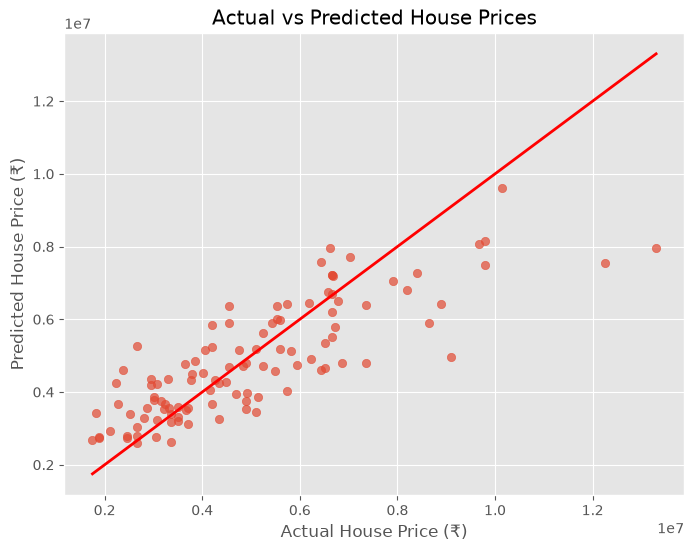

In [26]:
# ============================================
# Actual vs Predicted Prices
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual House Price (₹)")
plt.ylabel("Predicted House Price (₹)")
plt.title("Actual vs Predicted House Prices")

plt.show()

### 📌 Observation

The scatter plot compares the actual house prices with the predicted values generated by the Linear Regression model. Points closer to the red diagonal line indicate more accurate predictions.

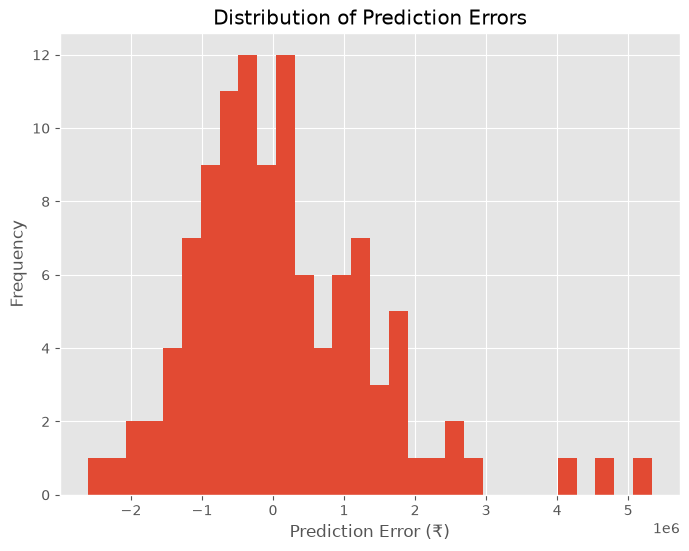

In [27]:
# ============================================
# Residual Error Distribution
# ============================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30)

plt.xlabel("Prediction Error (₹)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

### 📌 Observation

The residual distribution illustrates the prediction errors made by the model. A distribution centered around zero indicates that the model predictions are generally unbiased.

# 💾 Save the Trained Model

The trained Linear Regression model and the fitted StandardScaler are saved for use in the Flask web application.

In [28]:
# ============================================
# Save Model and Scaler
# ============================================

import joblib
import os

os.makedirs("../model", exist_ok=True)

joblib.dump(model, "../model/model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


# 🏠 Sample House Price Prediction

A sample house is used to demonstrate how the trained model predicts house prices.

In [29]:
# ============================================
# Sample Prediction
# ============================================

sample_house = X.iloc[[0]]

sample_house_scaled = scaler.transform(sample_house)

predicted_price = model.predict(sample_house_scaled)

print(f"Predicted House Price: ₹{predicted_price[0]:,.2f}")

Predicted House Price: ₹7,968,276.13


# 📝 Conclusion

In this project, a Linear Regression model was developed to predict house prices using various housing features. The dataset was cleaned, preprocessed, and encoded before splitting it into training and testing sets. Feature scaling was applied to improve model performance, and the trained model was evaluated using MAE, MSE, RMSE, and R² Score.

The trained model and scaler were saved successfully for deployment in a Flask web application. This model will serve as the prediction engine for the HousePriceAI web application.